# Fine-Grained Emotion Detection (8-label multi-label)  
### Team 6 — CSE 6363 
**Date:** Oct 24, 2025

This notebook fine-tunes **DistilBERT** on a curated subset of 8 emotions from the **GoEmotions** dataset.  
It includes:
- Multi-label emotion mapping (joy, surprise, anger, admiration, sadness, amusement, fear, love)  
- Stratified splitting to ensure balanced validation  
- Class-balanced fine-tuning with two-learning-rate optimization  
- Per-emotion threshold tuning for improved F1  
- Clean, human-readable inference results  

**Goal:** Build a compact, reproducible emotion classifier ready for deployment or presentation.


## 1) Install dependencies (runs in this kernel)

In [ ]:
# ✅ Install core libraries
%pip install -U transformers accelerate tqdm pandas numpy scikit-learn

# ✅ Install PyTorch (choose one; default CPU is safest and works everywhere)
# CPU-only (safe on any machine)
%pip install -U torch --index-url https://download.pytorch.org/whl/cpu

# If you *know* you have NVIDIA CUDA 12.x, you can instead use:
# %pip install -U torch --index-url https://download.pytorch.org/whl/cu121

%pip install -U datasets iterative-stratification

%pip install -U ipywidgets

# If you're on JupyterLab (not classic Notebook), also:
%pip install -U jupyterlab-widgets


# If installs just ran, it helps to restart the kernel once before training:
print("If this was the first time installing, please do: Kernel -> Restart, then run the next cells.")

## 2) Imports & configuration

In [2]:
import os, json, random, numpy as np, pandas as pd, torch
from sklearn.metrics import f1_score, precision_score, recall_score
from torch.utils.data import Dataset, DataLoader

# fixed imports
from transformers import AutoTokenizer, AutoModel
from transformers.optimization import get_cosine_schedule_with_warmup
from torch.optim import AdamW
from tqdm import tqdm
import torch.nn as nn

# <<< ADDED: Imports for plotting
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
# <<< END ADDED

SEED = 42
random.seed(SEED);
np.random.seed(SEED); 
torch.manual_seed(SEED);
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "distilbert-base-uncased"

# 8-label subset you’ll train on
EMOTIONS = ["joy","surprise","anger","admiration","sadness","amusement","fear","love"]

# training knobs for GoEmotions
MAX_LEN = 128
BATCH_SIZE = 16      # use 8 if memory is tight
EPOCHS = 5
LR = 5e-5            # backbone LR; head gets a higher LR below
OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

## 3) Data Pre-Processing

In [3]:
from datasets import concatenate_datasets, load_dataset
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

TARGET_LABELS = EMOTIONS

# full GoEmotions label list (dataset order)
ALL_LABELS = [
    "admiration","amusement","anger","annoyance","approval","caring","confusion","curiosity",
    "desire","disappointment","disapproval","disgust","embarrassment","excitement","fear",
    "gratitude","grief","joy","love","nervousness","optimism","pride","realization","relief",
    "remorse","sadness","surprise","neutral"
]
L2I = {l:i for i,l in enumerate(ALL_LABELS)}
keep_idx = [L2I[l] for l in TARGET_LABELS]

# load all splits and concatenate
ds = load_dataset("go_emotions")
full = concatenate_datasets([ds["train"], ds["validation"], ds["test"]])

# now these are regular Python lists
all_texts  = full["text"]
all_labels = full["labels"]

# convert list-of-ids -> 8 one-hot columns, ignoring 'neutral'
def to_vec(ids):
    s = set(ids)
    return [int(L2I[TARGET_LABELS[j]] in s) for j in range(len(TARGET_LABELS))]

mat = np.vstack([to_vec(ids) for ids in all_labels])
df  = pd.DataFrame({"text": all_texts})
for j, lab in enumerate(TARGET_LABELS):
    df[lab] = mat[:, j].astype(int)

# (optional) drop rows with no target emotions
df = df[df[TARGET_LABELS].sum(axis=1) > 0].reset_index(drop=True)

# multi-label stratified split (15% val)
X = df[["text"]].values
Y = df[TARGET_LABELS].values
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
train_idx, val_idx = next(msss.split(X, Y))
df_train = df.iloc[train_idx].reset_index(drop=True)
df_val   = df.iloc[val_idx].reset_index(drop=True)

print("Train:", len(df_train), "Val:", len(df_val))
print("Val positives per label:", dict(zip(TARGET_LABELS, Y[val_idx].sum(axis=0).astype(int))))

Train: 14452 Val: 2545
Val positives per label: {'joy': np.int64(268), 'surprise': np.int64(200), 'anger': np.int64(294), 'admiration': np.int64(768), 'sadness': np.int64(244), 'amusement': np.int64(434), 'fear': np.int64(115), 'love': np.int64(386)}


## 4) Tokenization, dataset, and dataloaders

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class EmotionDataset(Dataset):
    def __init__(self, frame, tokenizer, max_len):
        self.df = frame.reset_index(drop=True)
        self.tok = tokenizer; self.max_len = max_len
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        enc = self.tok(str(row["text"]), truncation=True, padding="max_length", max_length=self.max_len, return_tensors="pt")
        x = {k: v.squeeze(0) for k,v in enc.items()}
        y = torch.tensor(row[EMOTIONS].values.astype(np.float32))
        x["labels"] = y
        return x

train_ds = EmotionDataset(df_train, tokenizer, MAX_LEN)
val_ds   = EmotionDataset(df_val, tokenizer, MAX_LEN)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

print("Final Data Sizes (after fix):")
print("Train Dataloader batches:", len(train_dl), "Val Dataloader batches:", len(val_dl))

Final Data Sizes (after fix):
Train Dataloader batches: 904 Val Dataloader batches: 160


## 5) Model

In [5]:
import torch.nn as nn
from transformers import AutoModel

class Head(nn.Module):
    def __init__(self, hidden, out_dim):
        super().__init__()
        self.drop = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden, out_dim)
    def forward(self, x): return self.fc(self.drop(x))

class EmoModel(nn.Module):
    def __init__(self, model_name, out_dim):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        self.head = Head(self.backbone.config.hidden_size, out_dim)
    def forward(self, input_ids, attention_mask):
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:,0]
        return self.head(cls)

model = EmoModel(MODEL_NAME, len(EMOTIONS)).to(DEVICE)

# class balancing (GoEmotions is skewed)
freqs = df_train[EMOTIONS].mean(axis=0).values
pos_weight = torch.tensor((1 - freqs) / (freqs + 1e-6), dtype=torch.float32).to(DEVICE)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# two-LR optimizer: head learns faster
optimizer = AdamW(
    [
        {"params": model.head.parameters(), "lr": 3e-4},
        {"params": model.backbone.parameters(), "lr": LR},  #LR = 5e-5  
    ]
)
total_steps = max(1, len(train_dl)) * EPOCHS
scheduler = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=max(1, total_steps//10), num_training_steps=total_steps
)

sum(p.numel() for p in model.parameters())

66369032

## 6) Training

In [6]:
best_f1 = -1.0

# <<< ADDED: History object to store all metrics per epoch
history = {'train_loss': [], 'val_loss': [], 'val_micro_f1': []}
# <<< END ADDED

def compute_metrics(y_true, y_prob, thresh=0.5):
    y_pred = (y_prob >= thresh).astype(int)
    micro_f1 = f1_score(y_true, y_pred, average="micro", zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    micro_p = precision_score(y_true, y_pred, average="micro", zero_division=0)
    micro_r = recall_score(y_true, y_pred, average="micro", zero_division=0)
    per_label = {EMOTIONS[i]: f1_score(y_true[:,i], y_pred[:,i], zero_division=0) for i in range(len(EMOTIONS))}
    return {"micro_f1":micro_f1,"macro_f1":macro_f1,"micro_p":micro_p,"micro_r":micro_r, **{f"f1_{k}":v for k,v in per_label.items()}}

for epoch in range(1, EPOCHS+1):
    model.train()
    run_loss = 0.0
    for batch in tqdm(train_dl, desc=f"Train {epoch}/{EPOCHS}"):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = loss_fn(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        run_loss += loss.item()

    # ---- validation ----
    model.eval()
    probs, truths = [], []
    val_run_loss = 0.0 # <<< ADDED: Track validation loss
    
    with torch.no_grad():
        for batch in tqdm(val_dl, desc="Val"):
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            
            # <<< MODIFIED: Need labels on both CPU (for truths) and Device (for loss)
            labels_cpu = batch["labels"].cpu().numpy()
            labels_dev = batch["labels"].to(DEVICE)
            
            # <<< MODIFIED: Get logits once
            logits = model(input_ids, attention_mask)
            
            # <<< ADDED: Calculate validation loss
            v_loss = loss_fn(logits, labels_dev)
            val_run_loss += v_loss.item()
            
            p = torch.sigmoid(logits).cpu().numpy()
            probs.append(p); truths.append(labels_cpu) # <<< Use labels_cpu here
            
    y_prob = np.vstack(probs); y_true = np.vstack(truths)
    
    # <<< ADDED: Calculate average losses
    avg_train_loss = run_loss/max(1,len(train_dl))
    avg_val_loss = val_run_loss/max(1,len(val_dl))

    # print quick health stats
    print("Val positives:", {EMOTIONS[i]: int(y_true[:, i].sum()) for i in range(len(EMOTIONS))})

    # epoch display uses best global threshold (for readability)
    best_micro, best_t = 0.0, 0.5
    for t in np.linspace(0.25, 0.65, 17):
        f = f1_score(y_true, (y_prob >= t).astype(int), average="micro", zero_division=0)
        if f > best_micro: best_micro, best_t = f, t
    metrics = compute_metrics(y_true, y_prob, best_t)
    print(f"[metric threshold used this epoch: {best_t:.2f}]\n")
    
    # <<< MODIFIED: Print val_loss as well
    print(f"Epoch {epoch} loss={avg_train_loss:.4f} val_loss={avg_val_loss:.4f} micro_f1={metrics['micro_f1']:.4f} macro_f1={metrics['macro_f1']:.4f}\n")

    # <<< ADDED: Save all results to history
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_micro_f1'].append(metrics['micro_f1'])
    # <<< END ADDED

    # ---- checkpoint + artifacts ----
    if metrics["micro_f1"] > best_f1:
        best_f1 = metrics["micro_f1"]
        torch.save(model.state_dict(), os.path.join(OUT_DIR, "best_model.pt"))
        with open(os.path.join(OUT_DIR, "metrics_val.json"), "w") as f: json.dump(metrics, f, indent=2)

        # save backbone, tokenizer, labels
        model.backbone.save_pretrained(OUT_DIR)
        AutoTokenizer.from_pretrained(MODEL_NAME).save_pretrained(OUT_DIR)
        with open(os.path.join(OUT_DIR, "labels.json"), "w") as f: json.dump(EMOTIONS, f, indent=2)

        # <<< ADDED: Save best y_true and y_prob for PR curve
        np.save(os.path.join(OUT_DIR, "best_y_true.npy"), y_true)
        np.save(os.path.join(OUT_DIR, "best_y_prob.npy"), y_prob)
        # <<< END ADDED

        # per-label threshold tuning (0.30..0.70)
        best_thr = []
        for j in range(len(EMOTIONS)):
            best_f1_j, best_t_j = 0.0, 0.5
            for t in np.linspace(0.3, 0.7, 21):
                y_pred_j = (y_prob[:, j] >= t).astype(int)
                f1_j = f1_score(y_true[:, j], y_pred_j, zero_division=0)
                if f1_j > best_f1_j: best_f1_j, best_t_j = f1_j, t
            best_thr.append(float(best_t_j))
        with open(os.path.join(OUT_DIR, "thresholds.json"), "w") as f:
            json.dump({EMOTIONS[i]: best_thr[i] for i in range(len(EMOTIONS))}, f, indent=2)

print("Best micro-F1:", best_f1)

Val: 100%|████████████████████████████████████| 160/160 [00:56<00:00,  2.81it/s]


Val positives: {'joy': 268, 'surprise': 200, 'anger': 294, 'admiration': 768, 'sadness': 244, 'amusement': 434, 'fear': 115, 'love': 386}
[metric threshold used this epoch: 0.65]

Epoch 1 loss=0.5825 val_loss=0.3801 micro_f1=0.8139 macro_f1=0.7948



Val: 100%|████████████████████████████████████| 160/160 [00:37<00:00,  4.29it/s]


Val positives: {'joy': 268, 'surprise': 200, 'anger': 294, 'admiration': 768, 'sadness': 244, 'amusement': 434, 'fear': 115, 'love': 386}
[metric threshold used this epoch: 0.65]

Epoch 2 loss=0.2996 val_loss=0.4006 micro_f1=0.8245 macro_f1=0.8082



Val: 100%|████████████████████████████████████| 160/160 [00:42<00:00,  3.77it/s]


Val positives: {'joy': 268, 'surprise': 200, 'anger': 294, 'admiration': 768, 'sadness': 244, 'amusement': 434, 'fear': 115, 'love': 386}
[metric threshold used this epoch: 0.65]

Epoch 3 loss=0.1778 val_loss=0.4566 micro_f1=0.8261 macro_f1=0.8153



Val: 100%|████████████████████████████████████| 160/160 [00:43<00:00,  3.72it/s]


Val positives: {'joy': 268, 'surprise': 200, 'anger': 294, 'admiration': 768, 'sadness': 244, 'amusement': 434, 'fear': 115, 'love': 386}
[metric threshold used this epoch: 0.65]

Epoch 4 loss=0.1048 val_loss=0.5422 micro_f1=0.8327 macro_f1=0.8174



Val: 100%|████████████████████████████████████| 160/160 [00:40<00:00,  3.93it/s]


Val positives: {'joy': 268, 'surprise': 200, 'anger': 294, 'admiration': 768, 'sadness': 244, 'amusement': 434, 'fear': 115, 'love': 386}
[metric threshold used this epoch: 0.62]

Epoch 5 loss=0.0674 val_loss=0.5737 micro_f1=0.8344 macro_f1=0.8193

Best micro-F1: 0.8343536190133237


## 7) Plotting Results

Plotting learning curves...


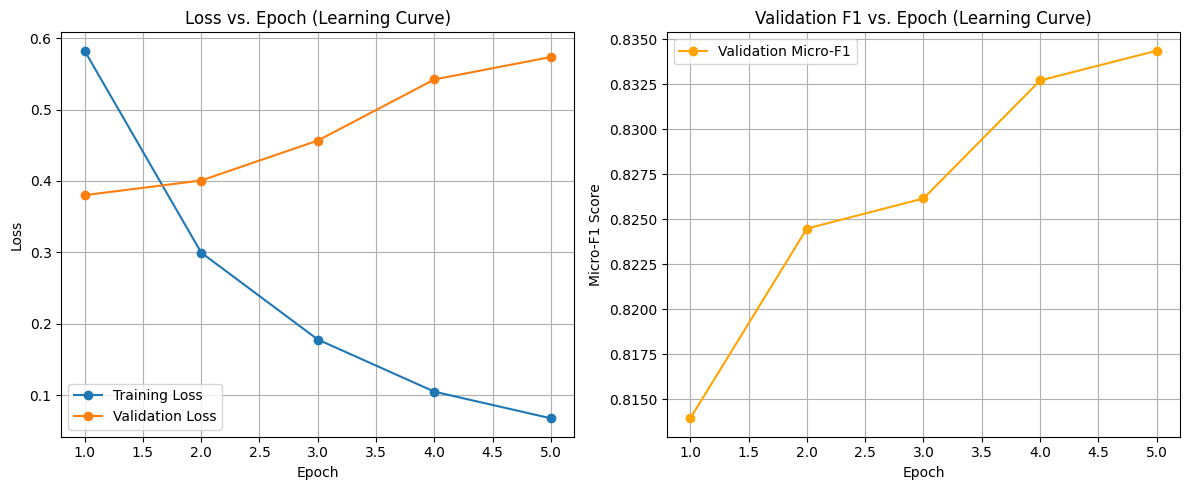

Plotting Precision-Recall curves...


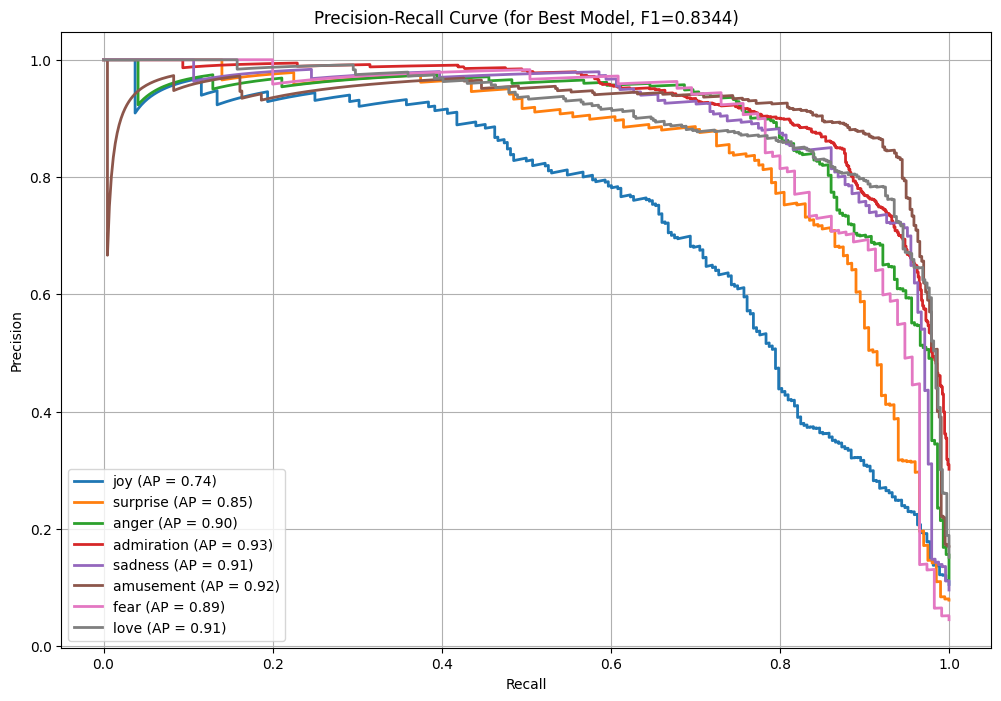

All plots saved to 'outputs' directory.


In [7]:
# <<< NEW CELL: Plotting all requested graphs >>>

print("Plotting learning curves...")
epochs_range = range(1, EPOCHS + 1) # Use this for x-axis

# --- Plot 1: Loss vs. Epoch (Train vs. Val) ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) # Create a figure with 2 side-by-side plots
plt.plot(epochs_range, history['train_loss'], label='Training Loss', marker='o')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', marker='o') # <<< ADDED val_loss
plt.title('Loss vs. Epoch (Learning Curve)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# --- Plot 2: Learning Curve (F1-Score vs. Epoch) ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['val_micro_f1'], label='Validation Micro-F1', marker='o', color='orange')
plt.title('Validation F1 vs. Epoch (Learning Curve)')
plt.xlabel('Epoch')
plt.ylabel('Micro-F1 Score')
plt.legend()
plt.grid(True)

plt.tight_layout() # Keeps plots from overlapping
plt.savefig(os.path.join(OUT_DIR, 'plot_learning_curves.png'))
plt.show()


# --- Plot 3: Precision-Recall (PR) Curve ---
print("Plotting Precision-Recall curves...")

try:
    y_true = np.load(os.path.join(OUT_DIR, "best_y_true.npy"))
    y_prob = np.load(os.path.join(OUT_DIR, "best_y_prob.npy"))

    plt.figure(figsize=(12, 8))
    for i in range(len(EMOTIONS)):
        precision, recall, _ = precision_recall_curve(y_true[:, i], y_prob[:, i])
        ap_score = average_precision_score(y_true[:, i], y_prob[:, i])
        plt.plot(recall, precision, lw=2, label=f'{EMOTIONS[i]} (AP = {ap_score:.2f})')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve (for Best Model, F1={best_f1:.4f})')
    plt.legend(loc='best')
    plt.grid(True)
    plt.savefig(os.path.join(OUT_DIR, 'plot_pr_curves.png'))
    plt.show()

except FileNotFoundError:
    print("\n[Error] Could not plot PR curve.")
    print("This happens if the model did not improve (e.g., if you only ran 1 epoch).")


print(f"All plots saved to '{OUT_DIR}' directory.")

## 8) Inference demo (single cell)

In [11]:
import numpy as np, torch, torch.nn as nn
from transformers import AutoTokenizer, AutoModel

class Head(nn.Module):
    def __init__(self, hidden, out_dim):
        super().__init__(); self.drop = nn.Dropout(0.2); self.fc = nn.Linear(hidden, out_dim)
    def forward(self, x): return self.fc(self.drop(x))

class EmoModel(nn.Module):
    def __init__(self, model_name, out_dim):
        super().__init__()
        try:
            self.backbone = AutoModel.from_pretrained(OUT_DIR)  # use saved backbone if present
        except Exception:
            self.backbone = AutoModel.from_pretrained(model_name)
        self.head = Head(self.backbone.config.hidden_size, out_dim)
    def forward(self, input_ids, attention_mask):
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        return self.head(out.last_hidden_state[:,0])

def load_for_infer(out_dir=OUT_DIR, model_name=MODEL_NAME):
    labels = json.load(open(os.path.join(out_dir, "labels.json")))
    tok = AutoTokenizer.from_pretrained(out_dir)
    model = EmoModel(model_name, len(labels))
    sd = torch.load(os.path.join(out_dir, "best_model.pt"), map_location="cpu")
    missing, unexpected = model.load_state_dict(sd, strict=False)
    print("state_dict load -> missing:", missing, "unexpected:", unexpected); model.eval()

    thr = np.full(len(labels), 0.5, dtype=float)
    tpath = os.path.join(out_dir, "thresholds.json")
    if os.path.exists(tpath):
        tmap = json.load(open(tpath)); thr = np.array([tmap[k] for k in labels], dtype=float)
        print("thresholds used:", thr.round(2).tolist())
    return tok, model, labels, thr

tok, infer_model, labels, thr = load_for_infer()

# simple readable output
def show_pretty(texts, tok, model, labels, thr, max_len=128, min_show=0.25):
    with torch.no_grad():
        for t in texts:
            enc = tok(t, truncation=True, padding="max_length", max_length=max_len, return_tensors="pt")
            p = torch.sigmoid(model(**enc)).numpy().ravel()
            top = np.argsort(p)[::-1]
            likely = f"{labels[top[0]]} ({p[top[0]]*100:.0f}%)" if p[top[0]] >= min_show else "uncertain"
            maybe  = f"{labels[top[1]]} ({p[top[1]]*100:.0f}%)"
            print(f"{t}\n  Likely: {likely}   ·   Maybe: {maybe}\n")

texts = [
    "I’m so proud of you!",
    "That jump scare really startled me",
    "I can’t stop laughing at this",
    "I’m upset about how this turned out",
    "You are sick",
    "You are so sweet",
    "I wish you did not loose your cool"
]


show_pretty(texts, tok, infer_model, labels, thr, max_len=MAX_LEN, min_show=0.25)



state_dict load -> missing: [] unexpected: []
thresholds used: [0.64, 0.7, 0.62, 0.62, 0.68, 0.62, 0.7, 0.36]
I’m so proud of you!
  Likely: admiration (100%)   ·   Maybe: joy (6%)

That jump scare really startled me
  Likely: fear (100%)   ·   Maybe: surprise (45%)

I can’t stop laughing at this
  Likely: amusement (99%)   ·   Maybe: anger (9%)

I’m upset about how this turned out
  Likely: sadness (100%)   ·   Maybe: anger (1%)

You are sick
  Likely: sadness (100%)   ·   Maybe: joy (1%)

You are so sweet
  Likely: admiration (98%)   ·   Maybe: love (60%)

I wish you did not loose your cool
  Likely: sadness (96%)   ·   Maybe: fear (13%)

